# 🌍 Global Payment Speed Inequality Analysis

## 📌 Project Overview

This project analyzes global disparities in electronic payment processing times using World Bank Enterprise Survey data.

The goal is to understand:

* How quickly businesses receive electronic payments across countries
* Whether global payment systems are improving over time
* The level of inequality in financial infrastructure

---

## 📊 Dataset Information

* **Source**: World Bank Enterprise Surveys
* **Indicator**: Days to receive the main type of electronic payment
* **Coverage**: 125 economies (2021–2025)
* **Unit**: Days

---

## 🧠 Key Questions

* Are payment systems becoming faster globally?
* Which countries are the fastest and slowest?
* How unequal are payment systems across the world?

---

## ⚙️ Methodology

1. Data cleaning and preprocessing
2. Column standardization
3. Aggregation by country
4. Exploratory data analysis (EDA)
5. Distribution and outlier analysis
6. Inequality measurement

---

## 📈 Expected Insights

* Identification of global trends
* Detection of outliers (very slow systems)
* Understanding of distribution patterns
* Measurement of global inequality

---

## ⚠️ Notes

* Data is self-reported by firms
* Some extreme values may reflect reporting bias
* Not all countries have time-series data

---

## 👨‍💻 Author

Burak Arı



In [28]:
# STEP 1: Import libraries and load dataset

import pandas as pd

# Load dataset
df = pd.read_csv("WB_ES_T_BREADY_FIN29.csv")

# Preview first rows
df.head()

# Show column names
df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID',
       'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE',
       'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'OBS_STATUS',
       'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')

In [29]:
# STEP 2: Basic data inspection

df.info()       # shows data types and null values
df.describe()   # summary statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               1494 non-null   object 
 1   STRUCTURE_ID            1494 non-null   object 
 2   ACTION                  1494 non-null   object 
 3   FREQ                    1494 non-null   object 
 4   FREQ_LABEL              1494 non-null   object 
 5   REF_AREA                1494 non-null   object 
 6   REF_AREA_LABEL          1494 non-null   object 
 7   INDICATOR               1494 non-null   object 
 8   INDICATOR_LABEL         1494 non-null   object 
 9   SEX                     1494 non-null   object 
 10  SEX_LABEL               1494 non-null   object 
 11  AGE                     1494 non-null   object 
 12  AGE_LABEL               1494 non-null   object 
 13  URBANISATION            1494 non-null   object 
 14  URBANISATION_LABEL      1494 non-null   

,TIME_PERIOD,OBS_VALUE,UNIT_MULT,TIME_FORMAT
count,1494.000000,1494.000000,1494.0,1494.0
mean,2023.742303,1.350867,0.0,602.0
std,0.824843,1.551463,0.0,0.0
min,2021.000000,0.000000,0.0,602.0
25%,2023.000000,0.458345,0.0,602.0
50%,2024.000000,0.949637,0.0,602.0
75%,2024.000000,1.623156,0.0,602.0
max,2025.000000,17.664782,0.0,602.0


In [30]:
# STEP 3: Clean dataset (correct version based on real columns)

# Select correct columns
df = df[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']].copy()

# Rename columns
df.columns = ['Country', 'Year', 'days_to_receive_payment']

# Convert Year to string
df['Year'] = df['Year'].astype(str)

# Remove non-year values like 'CCYY'
df = df[df['Year'].str.match(r'^\d{4}$')].copy()

# Convert Year to int
df['Year'] = df['Year'].astype(int)

# Drop missing values
df = df.dropna(subset=['days_to_receive_payment']).copy()

# Sort values
df = df.sort_values(['Country', 'Year']).copy()

# Reset index
df = df.reset_index(drop=True)

df.head()

/var/folders/hz/yr8j5zl90598zgvxg8xs50_80000gn/T/ipykernel_92893/3088848059.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Year'] = df['Year'].astype(str)
/var/folders/hz/yr8j5zl90598zgvxg8xs50_80000gn/T/ipykernel_92893/3088848059.

,Country,Year,days_to_receive_payment
0,Afghanistan,2025,0.865179
1,Afghanistan,2025,2.134830
2,Afghanistan,2025,0.782028
3,Afghanistan,2025,0.672386
4,Afghanistan,2025,0.890251


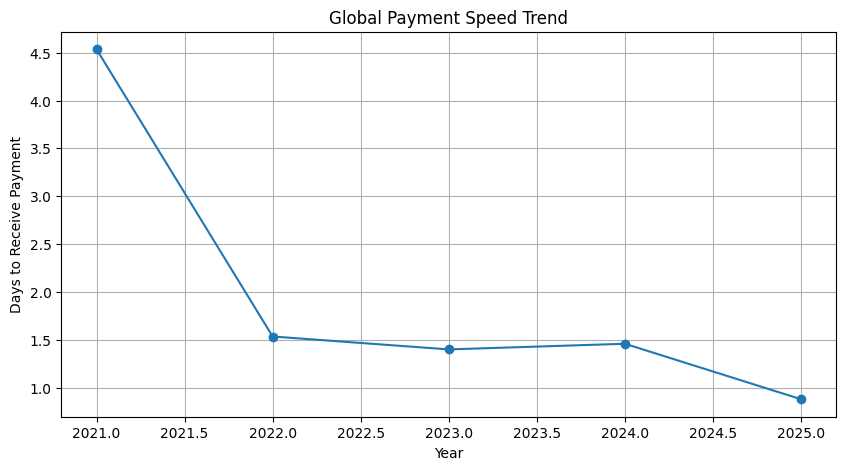

In [31]:
# STEP 4: Global trend analysis

import matplotlib.pyplot as plt

# Calculate yearly global average
global_trend = df.groupby('Year')['days_to_receive_payment'].mean()

# Plot the trend
plt.figure(figsize=(10,5))
plt.plot(global_trend, marker='o')

plt.title("Global Payment Speed Trend")
plt.xlabel("Year")
plt.ylabel("Days to Receive Payment")

plt.grid()
plt.show()

In [32]:
# STEP 5: Country ranking (fixed version)

# Get latest year
latest_year = df['Year'].max()

# Filter latest data
latest = df[df['Year'] == latest_year].copy()

# 🔥 IMPORTANT: Aggregate by country
latest = latest.groupby('Country')['days_to_receive_payment'].mean().reset_index()

# Sort by payment speed
latest = latest.sort_values('days_to_receive_payment')

# Top 10 fastest countries
fastest = latest.head(10)

# Top 10 slowest countries
slowest = latest.tail(10)

print("FASTEST COUNTRIES:")
print(fastest)

print("\nSLOWEST COUNTRIES:")
print(slowest)

FASTEST COUNTRIES:
                  Country  days_to_receive_payment
18                Nigeria                 0.000000
12                 Kuwait                 0.000000
21                Somalia                 0.043170
10                  Kenya                 0.044936
15               Mongolia                 0.122965
23                 Uganda                 0.132392
3                 Bolivia                 0.156327
20  Sao Tome and Principe                 0.218460
11               Kiribati                 0.239076
9           Guinea-Bissau                 0.243517

SLOWEST COUNTRIES:
                Country  days_to_receive_payment
4     Brunei Darussalam                 0.994377
0           Afghanistan                 1.035031
17                Niger                 1.491890
22  Trinidad and Tobago                 1.583598
5               Burundi                 1.615516
8                Guinea                 1.621803
1               Albania                 1.697105
6       

In [33]:
# STEP 6: Feature engineering

# Normalize year (important for model)
df['year_norm'] = df['Year'] - df['Year'].min()

# Create speed score (higher = faster system)
df['speed_score'] = 1 / (df['days_to_receive_payment'] + 0.0001)

df.head()

/var/folders/hz/yr8j5zl90598zgvxg8xs50_80000gn/T/ipykernel_92893/665136825.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['year_norm'] = df['Year'] - df['Year'].min()
/var/folders/hz/yr8j5zl90598zgvxg8xs50_80000gn/T/ipykernel_92893/6

,Country,Year,days_to_receive_payment,year_norm,speed_score
0,Afghanistan,2025,0.865179,4,1.155696
1,Afghanistan,2025,2.134830,4,0.468399
2,Afghanistan,2025,0.782028,4,1.278563
3,Afghanistan,2025,0.672386,4,1.487020
4,Afghanistan,2025,0.890251,4,1.123153


In [34]:
# STEP 7: Prepare data for model

from sklearn.model_selection import train_test_split

X = df[['year_norm']]
y = df['days_to_receive_payment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# STEP 8: Train model

from sklearn.ensemble import RandomForestRegressor

# Initialize model
model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train model
model.fit(X_train, y_train)

# Make predictions
pred = model.predict(X_test)

In [36]:
# STEP 9: Evaluate model

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 1.7277137317242433


In [37]:
# STEP 10: Future prediction

future_years = pd.DataFrame({
    'year_norm': range(df['year_norm'].max()+1, df['year_norm'].max()+6)
})

future_pred = model.predict(future_years)

print("Future predictions:", future_pred)

Future predictions: [0.86241852 0.86241852 0.86241852 0.86241852 0.86241852]


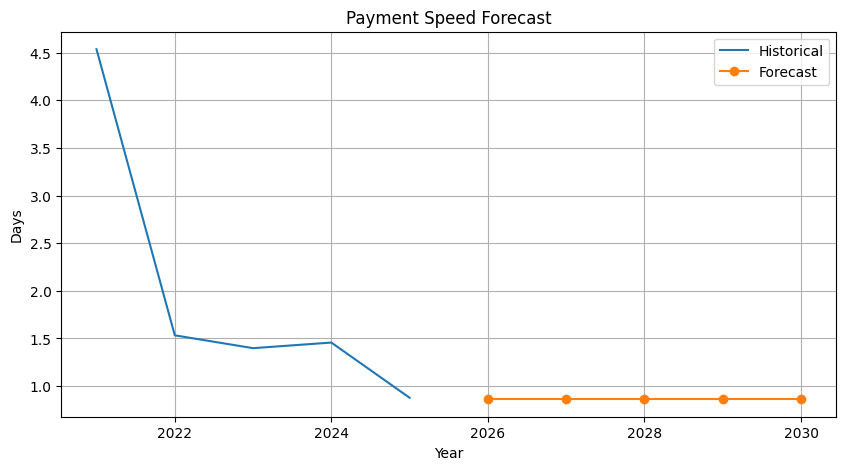

In [38]:
# STEP 11: Plot future predictions

plt.figure(figsize=(10,5))

# Plot historical data
plt.plot(df.groupby('Year')['days_to_receive_payment'].mean(), label='Historical')

# Plot future predictions
future_years_index = range(df['Year'].max()+1, df['Year'].max()+6)
plt.plot(future_years_index, future_pred, marker='o', label='Forecast')

plt.title("Payment Speed Forecast")
plt.xlabel("Year")
plt.ylabel("Days")

plt.legend()
plt.grid()
plt.show()

In [39]:
# STEP 12: Advanced outlier detection

# Calculate z-score
df['z_score'] = (
    df['days_to_receive_payment'] - df['days_to_receive_payment'].mean()
) / df['days_to_receive_payment'].std()

# Define outliers (very slow countries)
outliers = df[df['z_score'] > 2]

# Show results
outliers[['Country', 'Year', 'days_to_receive_payment']].sort_values(
    'days_to_receive_payment', ascending=False
).head(10)

/var/folders/hz/yr8j5zl90598zgvxg8xs50_80000gn/T/ipykernel_92893/211594883.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['z_score'] = (


,Country,Year,days_to_receive_payment
1324,Timor-Leste,2021,17.664782
1029,Papua New Guinea,2024,13.199737
1245,South Sudan,2024,9.797630
1484,West Bank and Gaza,2023,9.679943
609,Indonesia,2023,9.661708
1486,West Bank and Gaza,2023,9.656041
1488,West Bank and Gaza,2023,9.609526
1492,West Bank and Gaza,2023,9.581779
1490,West Bank and Gaza,2023,9.456298
1493,West Bank and Gaza,2023,9.443536


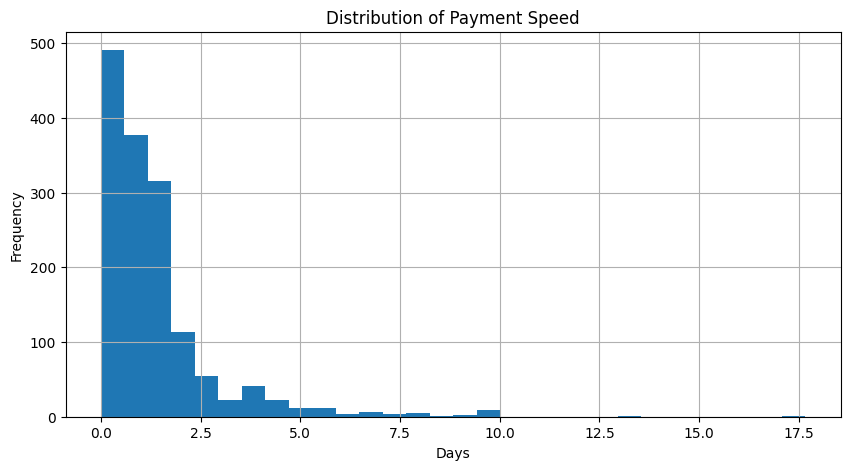

In [40]:
# STEP 13: Distribution of payment speed

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['days_to_receive_payment'], bins=30)

plt.title("Distribution of Payment Speed")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.grid()
plt.show()

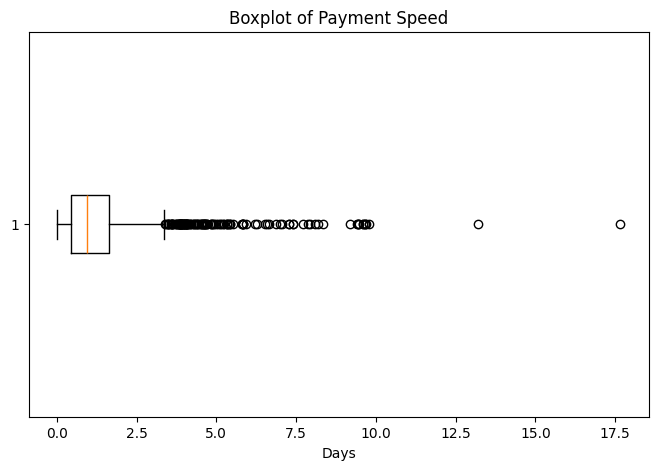

In [41]:
# STEP 13.5: Boxplot for outliers

plt.figure(figsize=(8,5))
plt.boxplot(df['days_to_receive_payment'], vert=False)

plt.title("Boxplot of Payment Speed")
plt.xlabel("Days")

plt.show()

In [42]:
# STEP 14: Inequality measure

q1 = df['days_to_receive_payment'].quantile(0.25)
q3 = df['days_to_receive_payment'].quantile(0.75)

iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR (spread):", iqr)

Q1: 0.45834499595
Q3: 1.6231563387499999
IQR (spread): 1.1648113427999998
